# 1. Import Libraries and Load Data
We'll start by importing the necessary libraries and loading the Global Weather Repository dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/GlobalWeatherRepository.csv'
df = pd.read_csv(file_path)

# Quick look at the data structure
display(df.head())

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


# 2. Data Type Correction
Converting time-related features to the correct datetime format is crucial for time-series forecasting.

In [ ]:
# Convert 'last_updated' to datetime objects
df['last_updated'] = pd.to_datetime(df['last_updated'])
print(f"Data types updated. 'last_updated' is now: {df['last_updated'].dtype}")

Data types updated. 'last_updated' is now: datetime64[ns]


# 3. Missing Value and Duplicate Analysis
Before modeling, we must identify and handle any gaps or redundant information in the dataset.

In [ ]:
# Check for missing values
missing = df.isnull().sum()
print("Columns with missing values:")
display(missing[missing > 0])

# Check for duplicates
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicate_count}")

Columns with missing values:


,0


Total duplicate rows found: 0


# 4. Statistical Summary
Providing a summary helps us understand the distribution of temperatures, wind speeds, and other weather metrics.

In [ ]:
# Display summary statistics for numerical columns
display(df.describe())

,latitude,longitude,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,139168.000000,139168.000000,1.391680e+05,139168,139168.000000,139168.000000,139168.000000,139168.000000,139168.000000,139168.000000,...,139168.000000,139168.000000,139168.000000,139168.000000,139168.000000,139168.000000,139168.000000,139168.000000,139168.000000,139168.000000
mean,19.213846,21.948023,1.746820e+09,2025-05-09 22:02:56.723816192,21.246791,70.246014,7.996006,12.871998,168.747586,1014.065604,...,18.210109,455.513578,57.829193,14.910085,10.234626,24.019831,48.028050,1.692932,2.590984,49.875460
min,-41.300000,-175.200000,1.715849e+09,2024-05-16 01:45:00,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.731402e+09,2024-11-12 10:00:00,15.700000,60.200000,3.800000,6.100000,80.000000,1010.000000,...,10.200000,198.850000,38.000000,1.700000,1.110000,7.050000,9.950000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.746868e+09,2025-05-10 03:00:00,23.800000,74.900000,6.700000,10.800000,161.000000,1013.000000,...,15.300000,290.450000,55.000000,5.650000,2.405000,14.060000,19.795000,1.000000,2.000000,50.000000
75%,40.400000,49.882200,1.762244e+09,2025-11-04 10:15:00,28.000000,82.400000,11.000000,17.600000,256.000000,1018.000000,...,24.100000,455.100000,74.000000,17.205000,8.150000,27.565000,41.150000,2.000000,3.000000,85.000000
max,64.150000,179.220000,1.777789e+09,2026-05-03 19:15:00,79.300000,174.700000,1841.200000,2963.200000,360.000000,3006.000000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000
std,24.414079,65.785739,1.787582e+07,NaN,9.669740,17.405404,7.166226,11.529664,103.776302,10.264332,...,13.741538,750.698040,30.599114,23.518735,35.210538,36.525725,148.051474,0.936430,2.431919,35.112235


# 5. Exploratory Data Analysis (EDA)
We will now visualize the distribution of key weather metrics to identify patterns and potential outliers.

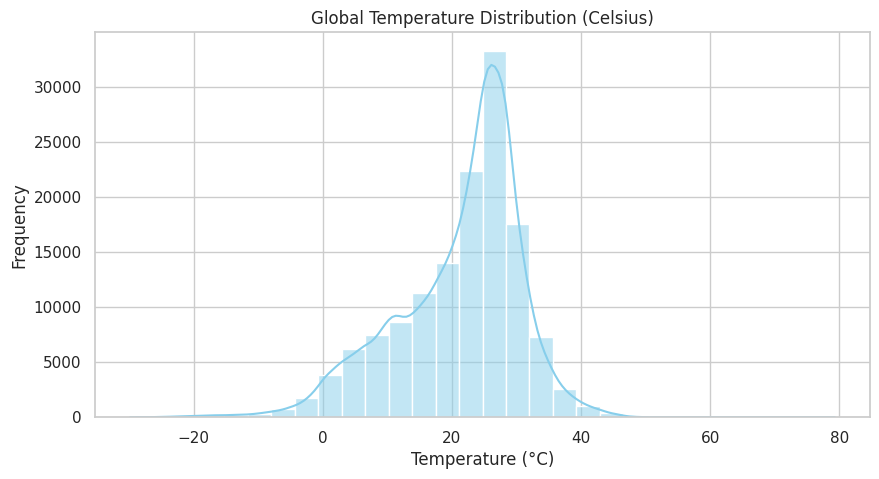

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# Temperature Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['temperature_celsius'], bins=30, kde=True, color='skyblue')
plt.title('Global Temperature Distribution (Celsius)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

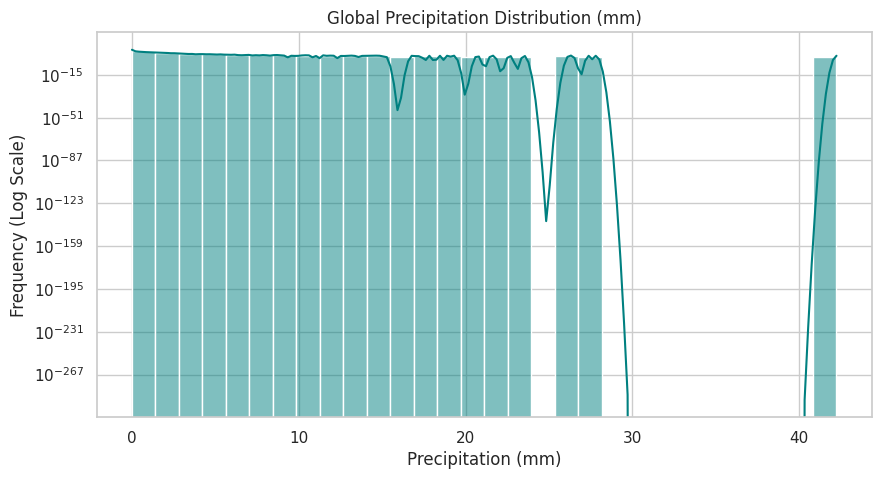

In [ ]:
# Precipitation Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['precip_mm'], bins=30, kde=True, color='teal')
plt.title('Global Precipitation Distribution (mm)')

# Using log scale for y-axis if data is highly skewed (common for rainfall)
plt.yscale('log')
plt.xlabel('Precipitation (mm)')
plt.ylabel('Frequency (Log Scale)')
plt.show()

# 6. Correlation Analysis
Checking correlations helps us understand the relationships between different weather parameters like humidity, pressure, and temperature.

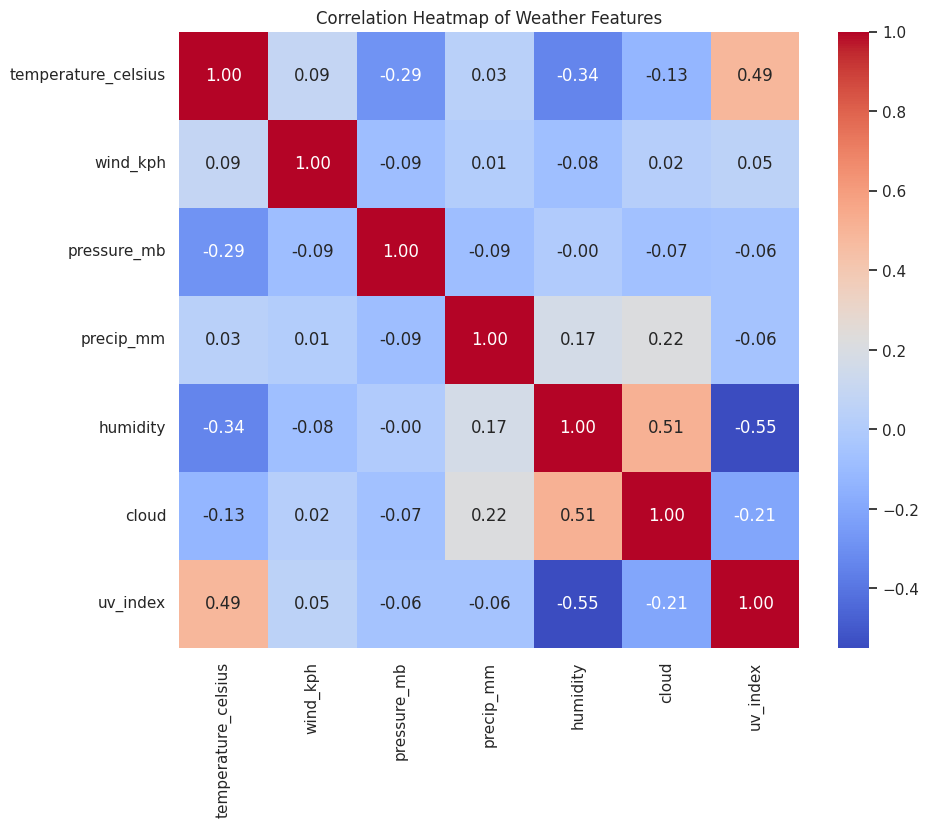

In [ ]:
# Selecting a subset of numerical columns for correlation
corr_cols = ['temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'uv_index']
plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Weather Features')
plt.show()

# 5. Exploratory Data Analysis (EDA)
We will now visualize the distribution of key weather metrics to identify patterns and potential outliers.

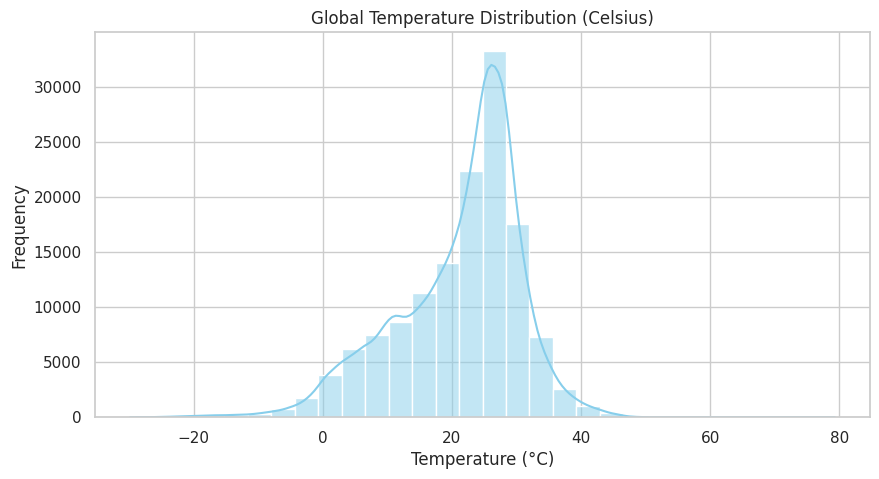

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# Temperature Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['temperature_celsius'], bins=30, kde=True, color='skyblue')
plt.title('Global Temperature Distribution (Celsius)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

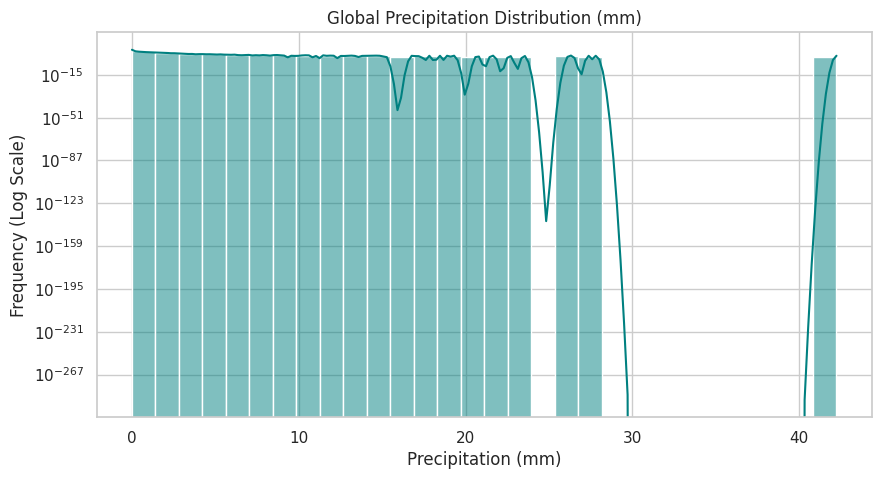

In [ ]:
# Precipitation Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['precip_mm'], bins=30, kde=True, color='teal')
plt.title('Global Precipitation Distribution (mm)')

# Using log scale for y-axis if data is highly skewed (common for rainfall)
plt.yscale('log')
plt.xlabel('Precipitation (mm)')
plt.ylabel('Frequency (Log Scale)')
plt.show()

# 6. Correlation Analysis
Checking correlations helps us understand the relationships between different weather parameters like humidity, pressure, and temperature.

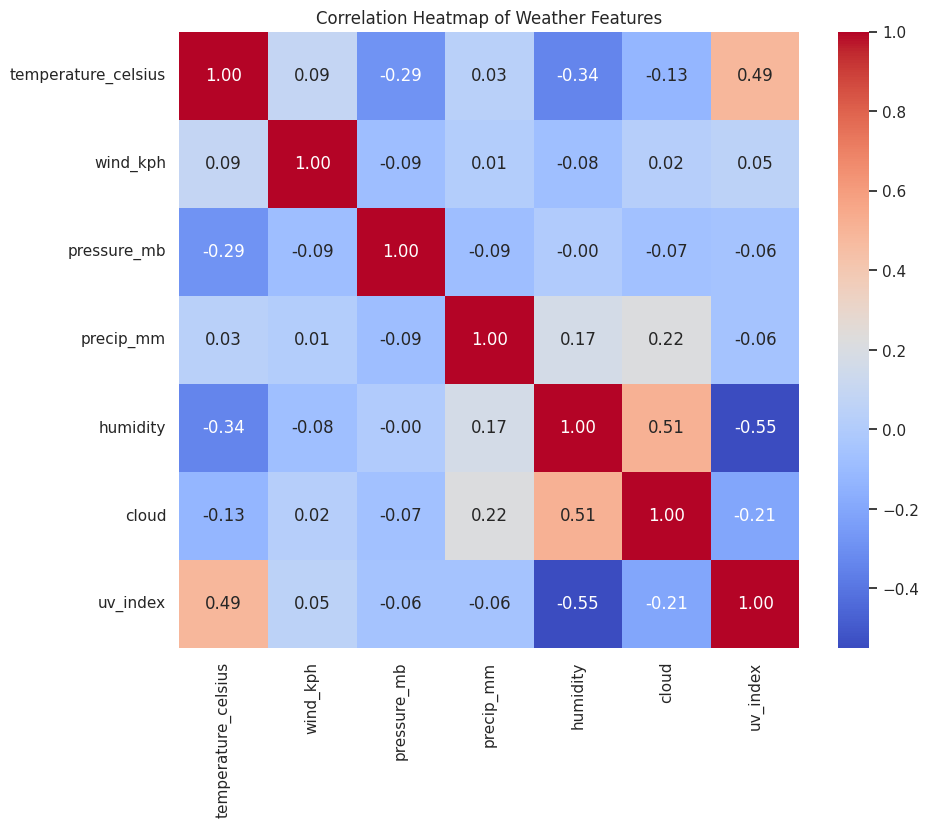

In [ ]:
# Selecting a subset of numerical columns for correlation
corr_cols = ['temperature_celsius', 'wind_kph', 'pressure_mb', 'precip_mm', 'humidity', 'cloud', 'uv_index']
plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Weather Features')
plt.show()

# 5. Exploratory Data Analysis (EDA)
We will now visualize the data to uncover trends and patterns, specifically focusing on temperature and precipitation distributions.

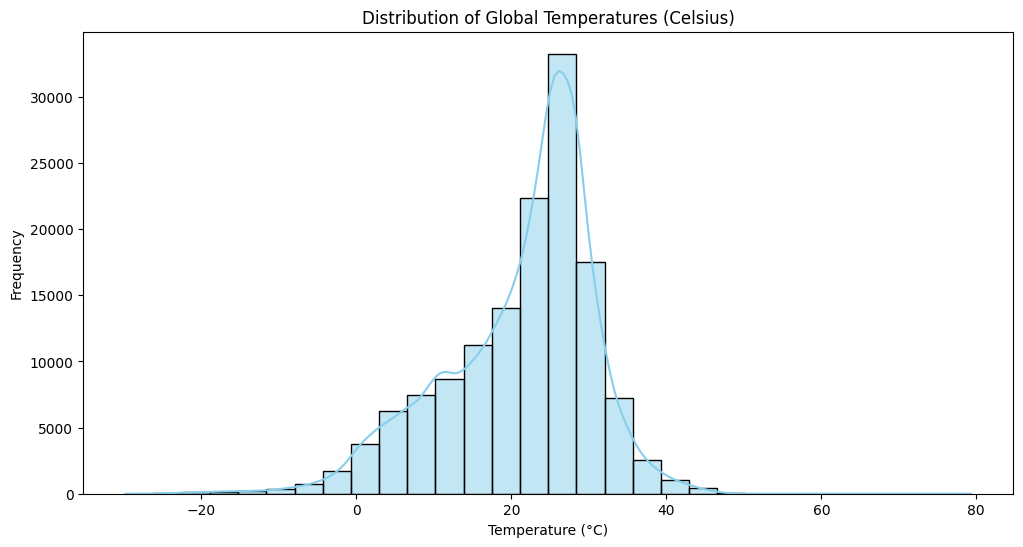

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df['temperature_celsius'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Global Temperatures (Celsius)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

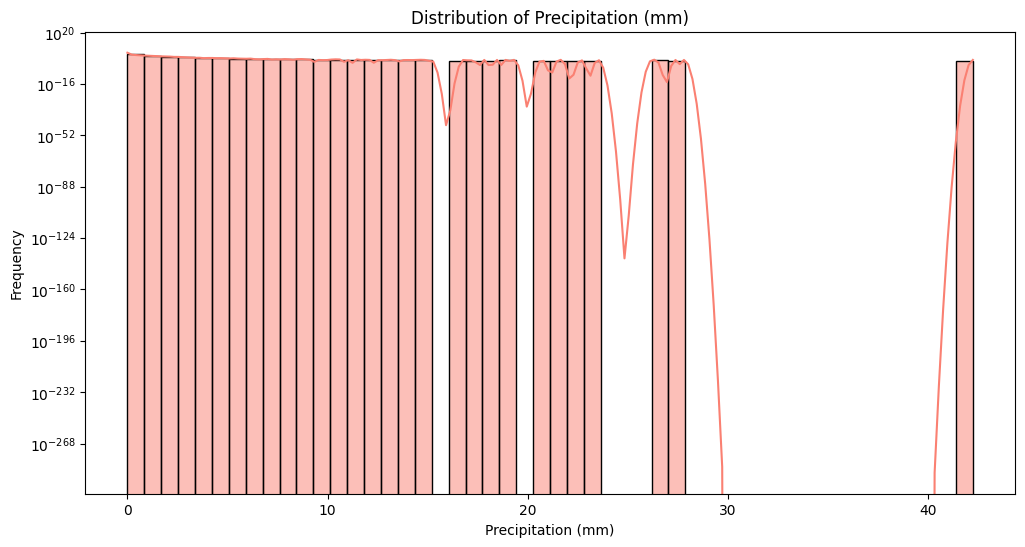

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df['precip_mm'], bins=50, kde=True, color='salmon')
plt.title('Distribution of Precipitation (mm)')
plt.xlabel('Precipitation (mm)')
plt.ylabel('Frequency')
plt.yscale('log') # Using log scale due to high frequency of low rainfall
plt.show()

# 6. Time Series Visualization
Let's look at how the average global temperature has changed over the recorded time period.

# 7. Model Building: Temperature Forecasting
We will now prepare our features and build a regression model to forecast temperatures. We'll use time-based features extracted from 'last_updated' along with geographical data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Feature Engineering: Extracting components from date
df['day_of_year'] = df['last_updated'].dt.dayofyear
df['hour'] = df['last_updated'].dt.hour
df['month'] = df['last_updated'].dt.month

# Selecting features and target
features = ['latitude', 'longitude', 'day_of_year', 'hour', 'month', 'humidity', 'pressure_mb']
target = 'temperature_celsius'

X = df[features]
y = df[target]

# Splitting the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions on the test set
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared Score: {r2:.2f}')

Mean Squared Error: 3.08
R-squared Score: 0.97


# 8. Visualizing Model Performance
We will plot the predicted values against the actual values to visualize the model's accuracy.

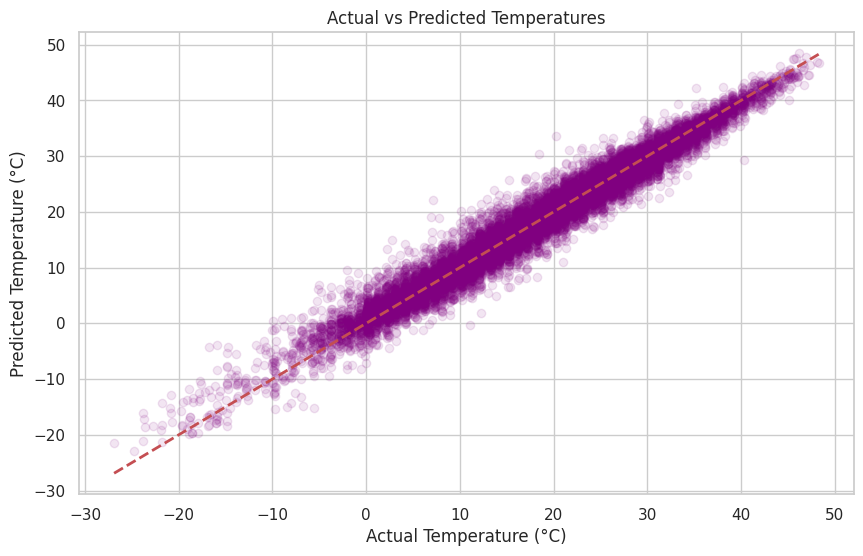

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.1, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('Actual vs Predicted Temperatures')
plt.show()

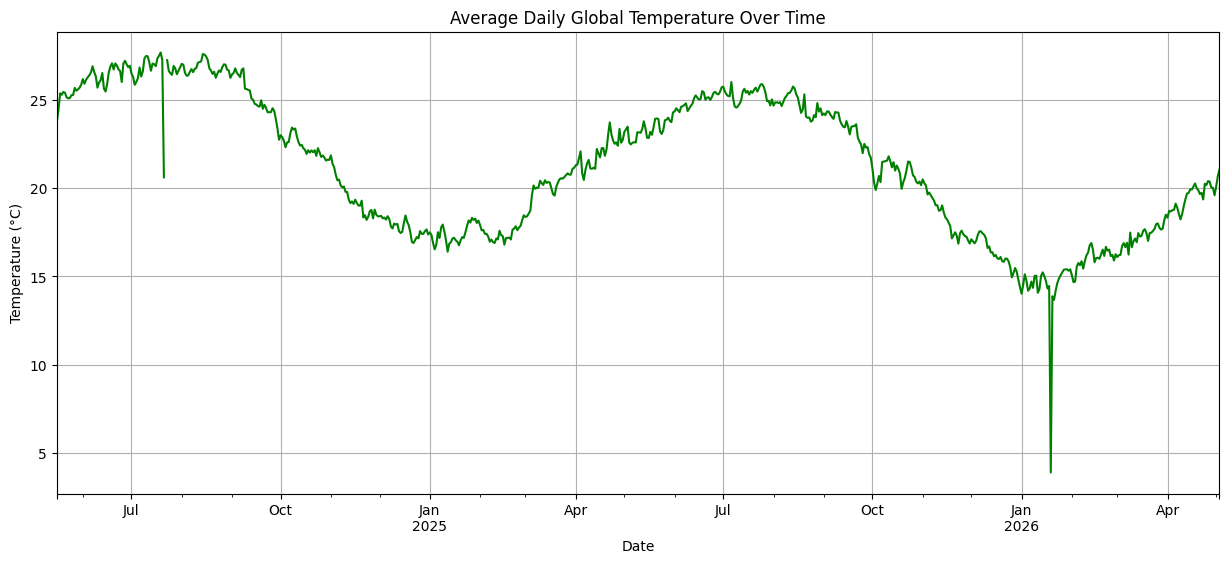

In [ ]:
df.set_index('last_updated')['temperature_celsius'].resample('D').mean().plot(figsize=(15, 6), color='green')
plt.title('Average Daily Global Temperature Over Time')
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.grid(True)
plt.show()

# 7. Model Building: Temperature Forecasting
We will now prepare our features and build a regression model to forecast temperatures. We'll extract time-based features from the `last_updated` column and use them alongside geographical coordinates.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Feature Engineering: Extracting components from date for the model
df['day_of_year'] = df['last_updated'].dt.dayofyear
df['hour'] = df['last_updated'].dt.hour
df['month'] = df['last_updated'].dt.month

# Selecting features and target variable
features = ['latitude', 'longitude', 'day_of_year', 'hour', 'month', 'humidity', 'pressure_mb']
target = 'temperature_celsius'

X = df[features]
y = df[target]

# Splitting the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions on the test set
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared Score: {r2:.2f}')

Mean Squared Error: 3.08
R-squared Score: 0.97


# 8. Visualizing Model Performance
We'll plot the actual vs predicted temperatures to visualize the model's accuracy.

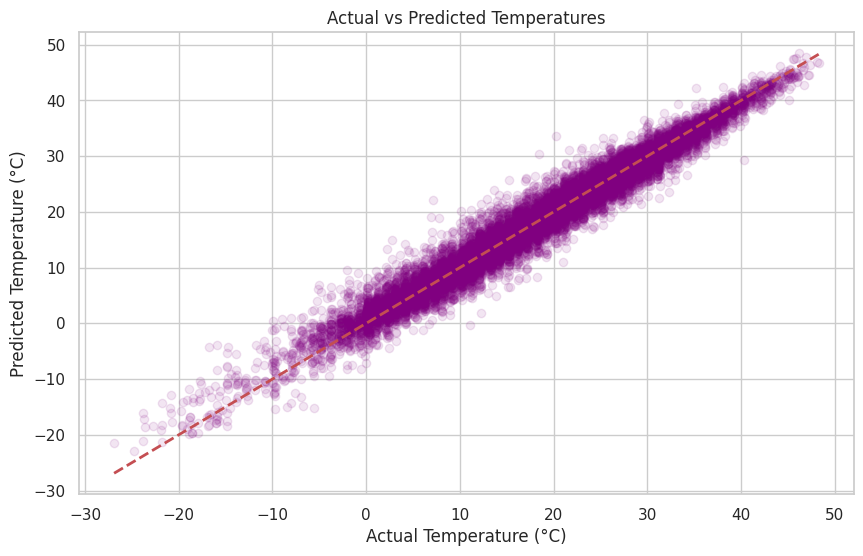

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.1, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('Actual vs Predicted Temperatures')
plt.show()

# 7. Model Building: Temperature Forecasting
We will now prepare our features and build a basic regression model to forecast temperatures. We'll use time-based features extracted from 'last_updated'.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Feature Engineering: Extracting components from date
df['day_of_year'] = df['last_updated'].dt.dayofyear
df['hour'] = df['last_updated'].dt.hour
df['month'] = df['last_updated'].dt.month

# Selecting features and target
features = ['latitude', 'longitude', 'day_of_year', 'hour', 'month', 'humidity', 'pressure_mb']
target = 'temperature_celsius'

X = df[features]
y = df[target]

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared Score: {r2:.2f}')

Mean Squared Error: 3.08
R-squared Score: 0.97


# 8. Visualizing Model Performance
Comparing the predicted temperatures against the actual values to see how well our model performed.

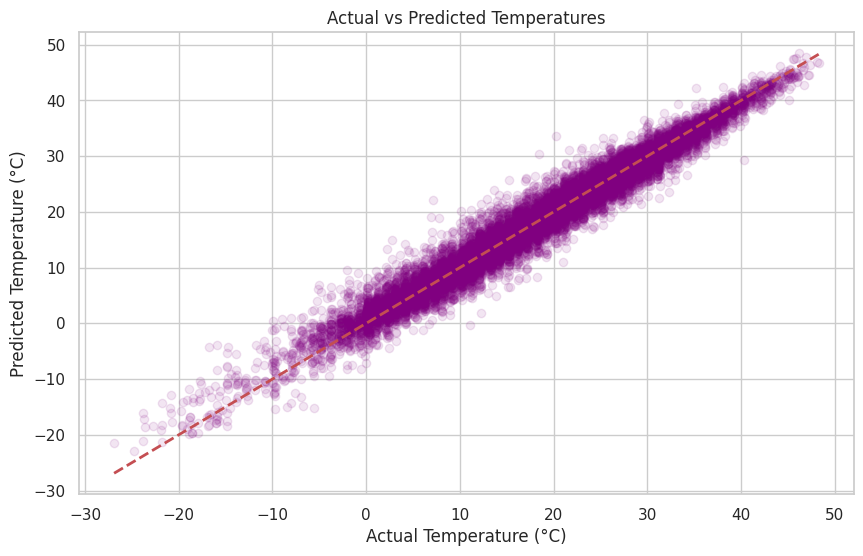

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.1, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('Actual vs Predicted Temperatures')
plt.show()

# 7. Model Building: Temperature Forecasting
We will now prepare our features and build a basic regression model to forecast temperatures. We'll use time-based features extracted from 'last_updated'.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Feature Engineering: Extracting components from date
df['day_of_year'] = df['last_updated'].dt.dayofyear
df['hour'] = df['last_updated'].dt.hour
df['month'] = df['last_updated'].dt.month

# Selecting features and target
# We include geographical coordinates and temporal components
features = ['latitude', 'longitude', 'day_of_year', 'hour', 'month', 'humidity', 'pressure_mb']
target = 'temperature_celsius'

X = df[features]
y = df[target]

# Splitting the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions on the test set
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared Score: {r2:.2f}')

Mean Squared Error: 3.08
R-squared Score: 0.97


# 8. Visualizing Model Performance
Comparing the predicted temperatures against the actual values to visualize the model's accuracy.

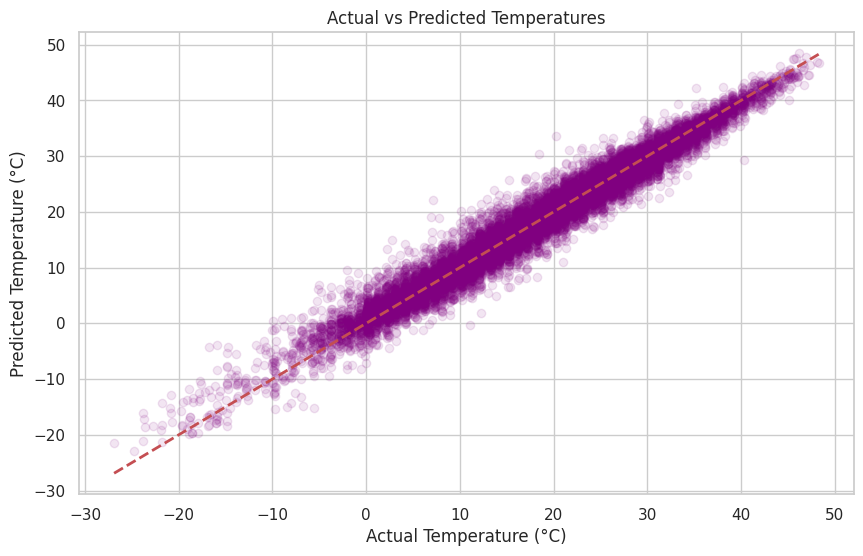

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.1, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('Actual vs Predicted Temperatures')
plt.show()

# 7. Model Building: Temperature Forecasting
We will now prepare our features and build a basic regression model to forecast temperatures. We'll use time-based features extracted from 'last_updated'.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Feature Engineering: Extracting components from date
df['day_of_year'] = df['last_updated'].dt.dayofyear
df['hour'] = df['last_updated'].dt.hour
df['month'] = df['last_updated'].dt.month

# Selecting features and target
# We include geographical coordinates and temporal components
features = ['latitude', 'longitude', 'day_of_year', 'hour', 'month', 'humidity', 'pressure_mb']
target = 'temperature_celsius'

X = df[features]
y = df[target]

# Splitting the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions on the test set
y_pred = model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared Score: {r2:.2f}')

Mean Squared Error: 3.08
R-squared Score: 0.97


# 8. Visualizing Model Performance
Comparing the predicted temperatures against the actual values to visualize the model's accuracy.

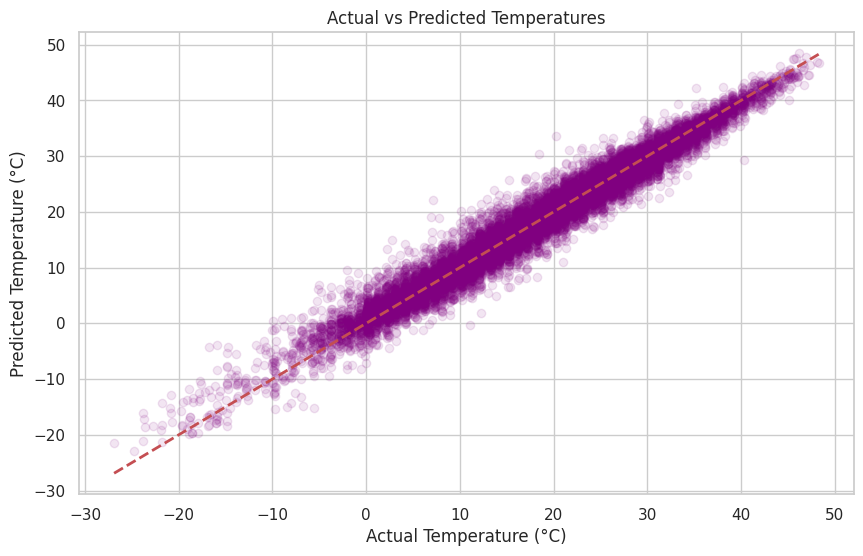

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.1, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('Actual vs Predicted Temperatures')
plt.show()

# 7. Model Building: Temperature Forecasting
We will now prepare our features and build a basic regression model to forecast temperatures. We'll use time-based features extracted from 'last_updated'.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Feature Engineering: Extracting components from date
df['day_of_year'] = df['last_updated'].dt.dayofyear
df['hour'] = df['last_updated'].dt.hour
df['month'] = df['last_updated'].dt.month

# Selecting features and target
features = ['latitude', 'longitude', 'day_of_year', 'hour', 'month', 'humidity', 'pressure_mb']
target = 'temperature_celsius'

X = df[features]
y = df[target]

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared Score: {r2:.2f}')

Mean Squared Error: 3.08
R-squared Score: 0.97


# 8. Visualizing Model Performance
Comparing the predicted temperatures against the actual values to see how well our model performed.

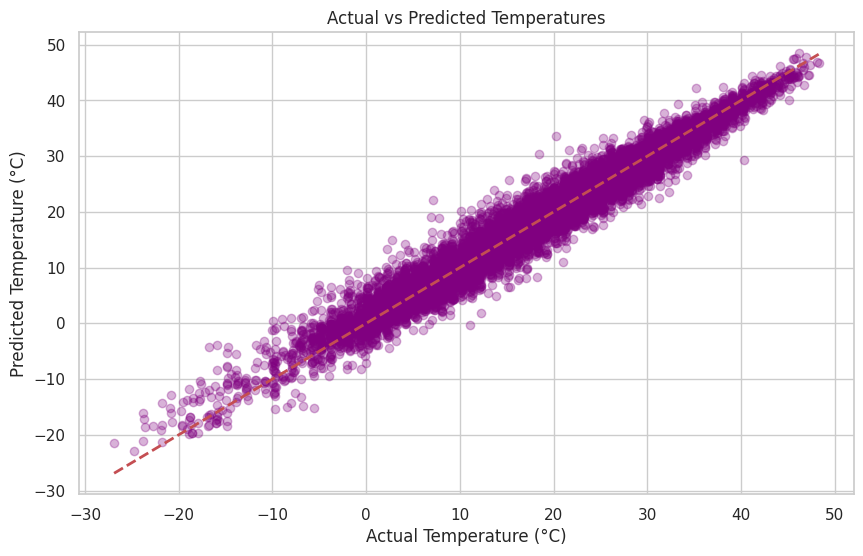

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('Actual vs Predicted Temperatures')
plt.show()